In [1]:
# ======================================================================
# SIMULATION LOOP
# ======================================================================

import math
import numpy as np
import pandas as pd

# SimGlucose imports
from simglucose.simulation.env import T1DSimEnv
from simglucose.controller.base import Controller, Action
from simglucose.sensor.cgm import CGMSensor
from simglucose.patient.t1dpatient import T1DPatient
try:
    from simglucose.actuator.pump import InsulinPump
except Exception:
    from simglucose.pump.pump import InsulinPump
from simglucose.simulation.scenario import CustomScenario

metadata = {
    "seed": 42,
    "patient": "adult#001",
    "sensor": "Dexcom",
    "start_time": "2025-04-19T21:00:00",
    "meals": [
        {"hour": 8,  "minute": 0,  "grams": 50.0},
        {"hour": 12, "minute": 30, "grams": 70.0},
        {"hour": 16, "minute": 0,  "grams": 15.0},
        {"hour": 19, "minute": 0,  "grams": 60.0},
    ],
    "controller": {
        "type": "MealBolusOnlyController",
        "basal_per_min": 0.006,
        "icr_g_per_u": 25.0,
    },
}

/Users/liuyushen/Desktop/compressed_POMDP/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Sim span: 2025-04-19 21:00:00 -> 2025-06-02 00:00:00 (days=44)
[RUN] step_min=3.0 min. Train until 2025-05-19 00:00:00, eval until 2025-06-02 00:00:00.
t= 2100 y= 198.7 iob= 2.15 dcgm=+13.1 pulse=+0.0705 choose= 0.0 risk=0.245 r0=0.245 minRisk=0.245 safeN= 1 qmix=   -11.0
t= 2200 y= 190.5 iob= 2.11 dcgm= +2.5 pulse=+0.0142 choose= 0.0 risk=0.067 r0=0.067 minRisk=0.067 safeN= 1 qmix=   -12.4
t= 2250 y= 149.2 iob= 2.16 dcgm= +5.4 pulse=+0.0358 choose= 0.0 risk=0.103 r0=0.103 minRisk=0.103 safeN= 1 qmix=   -11.6
t= 2600 y= 172.4 iob= 1.89 dcgm= +2.9 pulse=+0.0372 choose= 0.4 risk=0.247 r0=0.000 minRisk=0.000 safeN= 3 qmix=     2.4
t= 2700 y= 162.1 iob= 2.09 dcgm= -3.6 pulse=-0.0286 choose= 0.0 risk=0.004 r0=0.004 minRisk=0.004 safeN= 1 qmix=    -2.2
t= 2800 y= 156.4 iob= 2.19 dcgm= +6.5 pulse=+0.0508 choose= 0.0 risk=0.034 r0=0.034 minRisk=0.034 safeN= 1 qmix=    -3.4
t= 3150 y= 167.1 iob= 2.20 dcgm= +6.4 pulse=+0.0518 choose= 0.0 risk=0.000 r0=0.000 minRisk=0.000 safeN= 1 qmix=     2.9
t

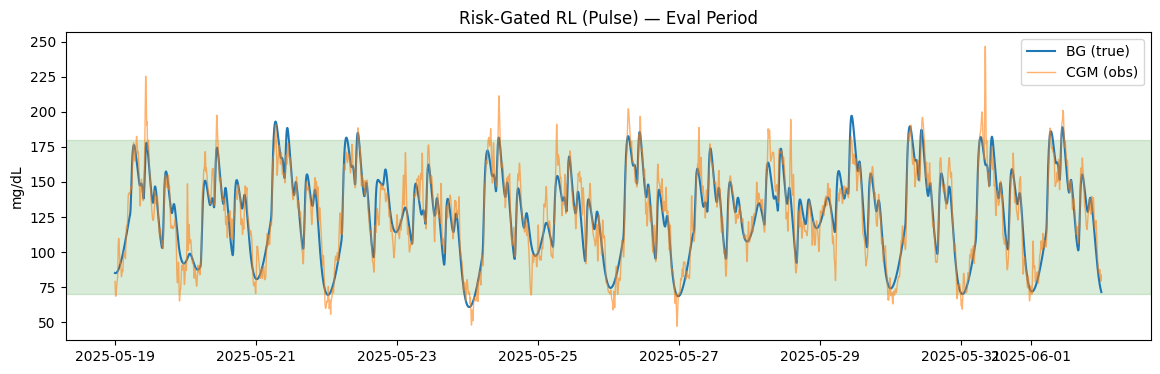

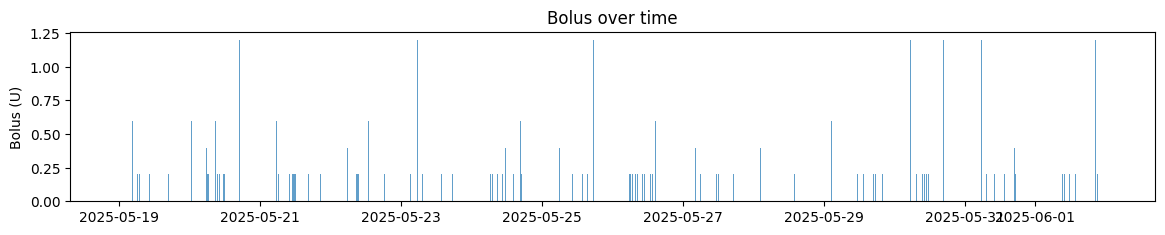

In [11]:
# ==============================================================================
# Compressed POMDP + Risk-Gated RL  (v4 — Pulse-Based Risk)
# ==============================================================================
# Complete redesign: replaces MC-rollout risk with a learned pulse predictor.
#
# Architecture:
#   1. PulsePredictor: small MLP that predicts p_t ≈ ln(CGM_{t+1}/CGM_t)
#      from a sliding window of (CGM, dCGM, bolus, IOB) features.
#   2. Analytical risk: ρ(a) measures how much the pulse-adjusted glucose
#      would exceed the safe corridor [G_l, G_u], relative to current glucose.
#   3. ProxyFeaturizer: builds o_t = [CGM, dCGM, last_bolus, IOB] (normalized).
#   4. QEnsemble + risk-gated Qmix policy (unchanged from paper).
#   5. MealBolusTeacher for warmup (unchanged).
#
# No MC rollouts, no IOB ceilings, no BG-adaptive RMAX hacks.
# The pulse predictor learns the dynamics; the risk formula handles safety.
# ==============================================================================

from collections import deque
from dataclasses import dataclass
from typing import Deque, Dict, Optional, Tuple, List

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# ======================================================================
# Helpers (same as before — included for completeness)
# ======================================================================
def _env_step_minutes(env) -> float:
    from datetime import timedelta
    st = getattr(env, 'sample_time', timedelta(minutes=3))
    if isinstance(st, timedelta):
        return float(st.total_seconds() / 60.0)
    try:
        return float(st) if st else 3.0
    except Exception:
        return 3.0


def _extract_now(info: dict, default=None):
    if isinstance(info, dict):
        if 'current_time' in info:
            return pd.to_datetime(info['current_time'])
        if 'time' in info:
            return pd.to_datetime(info['time'])
    return default


def _get_cgm(observation, info=None, env=None) -> float:
    try:
        for attr in ('CGM', 'cgm'):
            if hasattr(observation, attr):
                return float(getattr(observation, attr))
    except Exception:
        pass
    if hasattr(observation, '__len__') and len(observation) > 0:
        try:
            return float(observation[0])
        except Exception:
            pass
    if isinstance(info, dict):
        for k in ('CGM', 'cgm'):
            if k in info and info[k] is not None:
                try:
                    return float(info[k])
                except Exception:
                    pass
    return float('nan')


def get_true_bg(observation, info=None, env=None) -> float:
    if isinstance(info, dict):
        for k in ('BG', 'bg', 'PlasmaGlucose', 'plasma_glucose'):
            if k in info and info[k] is not None:
                try:
                    return float(info[k])
                except Exception:
                    pass
    try:
        p = getattr(env, 'patient', None)
        st = getattr(p, '_state', None) or getattr(p, 'state', None)
        if st is not None and hasattr(st, 'G'):
            return float(getattr(st, 'G'))
    except Exception:
        pass
    if hasattr(observation, '__len__') and len(observation) > 0:
        try:
            return float(observation[0])
        except Exception:
            pass
    return float(observation)


def _kovatchev_risk(bg: float) -> tuple:
    if not np.isfinite(bg) or bg <= 0:
        return 0.0, 0.0, 0.0
    f = 1.509 * (np.log(bg) ** 1.084 - 5.381)
    risk = 10.0 * (f ** 2)
    lbgi = risk if f < 0 else 0.0
    hbgi = risk if f > 0 else 0.0
    return float(lbgi), float(hbgi), float(risk)


# ======================================================================
# Reward Function
# ======================================================================
def rl_shaped_reward(bg: float, last_bolus: float = 0.0,
                     target=(100.0, 160.0)) -> float:
    """
    Shaped reward: aggressive hypo penalty, mild hyper penalty,
    with action modifiers for anti-stacking and proactive correction.
    """
    lo, hi = target

    # Hypoglycemia
    if bg < 60:
        base = -160.0 - 4.0 * ((60 - bg) / 5.0)
    elif bg < 70:
        base = -100.0 - 3.0 * ((70 - bg) / 5.0)
    elif bg < 80:
        base = -40.0 - 1.5 * ((80 - bg) / 5.0)
    elif 80 <= bg < 100:
        d = (100 - bg) / 10.0
        base = -0.8 * (d ** 2)

    # Near-target
    elif 100 <= bg < lo:
        d = (lo - bg) / 10.0
        base = 4.0 - 0.5 * (d ** 2)

    # Target zone
    elif lo <= bg <= hi:
        base = 4.0

    # Hyperglycemia
    elif hi < bg <= 160:
        d = (bg - hi) / 20.0
        base = 0.8 - 1.0 * (d ** 2)
    elif 160 < bg <= 200:
        d = (bg - 160) / 10.0
        base = -1.5 - 1.0 * (d ** 2)
    elif 200 < bg <= 250:
        d = (bg - 200) / 10.0
        base = -12.0 - 2.0 * (d ** 2)
    else:
        d = (bg - 250) / 10.0
        base = -40.0 - 3.0 * (d ** 2)

    # Action modifiers
    if last_bolus > 0.0 and bg < 110:
        base -= 5.0 * float(last_bolus)
    elif last_bolus > 0.0 and bg > 180:
        if bg > 250:
            base += 15.0 * float(last_bolus)
        elif bg > 200:
            base += 12.0 * float(last_bolus)
        else:
            base += 8.0 * float(last_bolus)

    return float(base)


# ======================================================================
# MealBolusTeacher (unchanged)
# ======================================================================
class MealBolusTeacher(Controller):
    def __init__(self, basal_per_min: float, icr_g_per_u: float,
                 cf_mg_per_u: float = 50.0, target_bg: float = 130.0):
        super().__init__(init_state=None)
        self.basal = float(basal_per_min)
        self.icr = float(icr_g_per_u)
        self.cf = float(cf_mg_per_u)
        self.target_bg = float(target_bg)
        self.last_correction_h = -999.0

    def policy(self, observation, reward, done, **info):
        env = info.get("env", None)
        now_dt = _extract_now(info, default=None)

        grams = 0.0
        h_now = 0.0
        if env is not None and now_dt is not None:
            start = getattr(env.scenario, 'start_time', None)
            meals = getattr(env.scenario, 'scenario', [])
            if start and meals:
                h_now = (now_dt - start).total_seconds() / 3600.0
                win_h = 5.0 / 60.0
                for (mh, g) in meals:
                    if abs(mh - h_now) <= win_h + 1e-9:
                        grams = float(g)
                        break

        meal_bolus = grams / max(self.icr, 1e-6)

        correction_bolus = 0.0
        cgm = _get_cgm(observation, info, env)
        if np.isfinite(cgm) and cgm > 180.0 and grams == 0.0:
            if (h_now - self.last_correction_h) > 2.0:
                correction_bolus = (cgm - self.target_bg) / max(self.cf, 1e-6)
                self.last_correction_h = h_now

        total_bolus = float(np.clip(meal_bolus + correction_bolus, 0.0, 3.0))
        return Action(basal=self.basal, bolus=total_bolus)


# ======================================================================
# ProxyFeaturizer — builds o_t and maintains history window
# ======================================================================
class ProxyFeaturizer:
    """
    Builds normalized o_t = [CGM_norm, dCGM_norm, bolus_norm, IOB_norm].
    Also maintains a sliding window of raw features for the pulse predictor.
    """
    def __init__(self, iob_decay_rate: float = 0.98, window_size: int = 8):
        self.prev_cgm: Optional[float] = None
        self.iob: float = 0.0
        self.decay_rate = float(iob_decay_rate)
        self.window_size = int(window_size)
        # History window: each entry is [cgm_norm, dcgm_norm, bolus_norm, iob_norm]
        self.history: Deque[np.ndarray] = deque(maxlen=self.window_size)

    def o_vec(self, cgm: float, last_bolus: float) -> np.ndarray:
        if self.prev_cgm is None or not np.isfinite(self.prev_cgm):
            dcgm = 0.0
        else:
            dcgm = float(cgm - self.prev_cgm)
        self.prev_cgm = float(cgm)

        self.iob = (self.iob * self.decay_rate) + float(last_bolus)

        norm_cgm = (float(cgm) - 120.0) / 100.0
        norm_dcgm = float(dcgm) / 10.0
        norm_bolus = float(last_bolus) / 2.0
        norm_iob = float(self.iob) / 5.0

        o = np.array([norm_cgm, norm_dcgm, norm_bolus, norm_iob], dtype=np.float32)
        self.history.append(o.copy())
        return o

    def get_window(self) -> np.ndarray:
        """Return (window_size, 4) array, zero-padded if history is short."""
        if len(self.history) == 0:
            return np.zeros((self.window_size, 4), dtype=np.float32)
        arr = np.array(list(self.history), dtype=np.float32)  # (T, 4)
        if arr.shape[0] < self.window_size:
            pad = np.zeros((self.window_size - arr.shape[0], 4), dtype=np.float32)
            arr = np.concatenate([pad, arr], axis=0)
        return arr

    def reset(self):
        self.prev_cgm = None
        self.iob = 0.0
        self.history.clear()


# ======================================================================
# PulsePredictor — learns p_t ≈ ln(CGM_{t+1} / CGM_t)
# ======================================================================
class PulsePredictor(nn.Module):
    """
    Small MLP that takes a window of recent observations + a candidate
    action and predicts the log-return of glucose: p = ln(CGM_{t+1}/CGM_t).

    Input:  [flattened history window (window_size * 4), candidate_bolus_norm]
    Output: scalar p_t ∈ (-∞, +∞), though in practice |p| < 0.3 or so.

    Training target: ln(CGM_{t+1} / CGM_t) observed from the environment.
    """
    def __init__(self, window_size: int = 8, obs_dim: int = 4, hid: int = 64):
        super().__init__()
        input_dim = window_size * obs_dim + 1  # +1 for candidate bolus
        self.net = nn.Sequential(
            nn.Linear(input_dim, hid),
            nn.ReLU(),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Linear(hid, 1)
        )

    def forward(self, window_flat: torch.Tensor, bolus_norm: torch.Tensor) -> torch.Tensor:
        """
        window_flat: (B, window_size * obs_dim)
        bolus_norm:  (B, 1)
        returns:     (B,) predicted pulse
        """
        x = torch.cat([window_flat, bolus_norm], dim=-1)
        return self.net(x).squeeze(-1)


@dataclass
class PulseTrainSample:
    """One training sample for the pulse predictor."""
    window_flat: np.ndarray   # (window_size * 4,)
    bolus_norm: float         # normalized bolus taken
    target_p: float           # ln(CGM_{t+1} / CGM_t)


# ======================================================================
# Analytical Risk from Pulse
# ======================================================================
def pulse_risk(cgm: float, pulse: float,
               candidate_bolus: float = 0.0,
               current_iob: float = 0.0,
               delta_cgm: float = 0.0,
               g_low: float = 70.0, g_high: float = 180.0) -> float:
    """
    v4.5: Stronger zero-bolus risk signal during active drops.
 
    For non-zero bolus: same as v4.4 (IOB sigmoid + margin + trend).
    For zero bolus: risk reflects trajectory danger, not just IOB level.
    """
    predicted = cgm * math.exp(float(pulse))
 
    # --- Pulse-based risk ---
    viol_after = max(predicted - g_high, 0.0) + max(g_low - predicted, 0.0)
    viol_before = max(cgm - g_high, 0.0) + max(g_low - cgm, 0.0)
    raw = max(viol_after - viol_before, 0.0)
    absolute = viol_after
    pulse_component = (raw + 0.3 * absolute) / 100.0
 
    # --- PK prior for NON-ZERO bolus (unchanged from v4.4) ---
    total_insulin = current_iob + candidate_bolus
 
    k_iob = 4.0
    iob_risk = (total_insulin ** 2) / (total_insulin ** 2 + k_iob ** 2)
 
    margin = max(cgm - g_low, 5.0)
    insulin_impact = total_insulin * 8.0
    margin_risk = insulin_impact / (margin + insulin_impact)
 
    trend_penalty = 0.0
    if delta_cgm < -1.0 and current_iob > 0.5:
        fall_severity = min(abs(delta_cgm) / 5.0, 1.0)
        iob_severity = min(current_iob / 4.0, 1.0)
        trend_penalty = 0.20 * fall_severity * iob_severity
 
    pk_prior = max(iob_risk, margin_risk) + trend_penalty
    pk_prior = float(np.clip(pk_prior, 0.0, 0.95))
 
    # --- ZERO-BOLUS RISK (rewritten in v4.5) ---
    if candidate_bolus <= 0.0:
        # For zero bolus, risk should reflect "how dangerous is the current
        # trajectory" — this is a SIGNAL for learning, not for action blocking.
        #
        # Three components:
        #
        # A. Proximity risk: how close is CGM to the hypo boundary?
        #    At CGM=120 → 0.0, CGM=100 → 0.25, CGM=80 → 0.64, CGM=70 → 1.0
        proximity = max(0.0, 1.0 - (cgm - g_low) / 60.0) ** 2
 
        # B. Momentum risk: if CGM is dropping, project where it's heading.
        #    At dCGM=-3 (dropping 1 mg/dL/min), project 30 min = -30 mg/dL.
        #    Risk based on projected CGM proximity to hypo.
        momentum = 0.0
        if delta_cgm < 0:
            projected_cgm = cgm + delta_cgm * 10.0  # ~30 min projection
            projected_cgm = max(projected_cgm, 30.0)
            momentum = max(0.0, 1.0 - (projected_cgm - g_low) / 60.0) ** 2
 
        # C. IOB drag: active insulin will continue pushing BG down.
        #    Even if CGM is stable now, IOB=2 means more drops coming.
        iob_drag = 0.0
        if current_iob > 0.3:
            # Each unit of IOB could drop BG by ~30-50 over its lifetime.
            # Estimate remaining impact on margin.
            remaining_drop = current_iob * 15.0  # conservative: 15 mg/dL per U remaining
            effective_margin = max(cgm - g_low - remaining_drop, 5.0)
            iob_drag = max(0.0, 1.0 - effective_margin / 60.0) ** 1.5
 
        # Combine: take the max of all three signals
        zero_risk = max(proximity, momentum, iob_drag)
        zero_risk = float(np.clip(zero_risk, 0.0, 0.95))
 
        # Also consider pulse component
        combined = max(pulse_component, zero_risk)
        return float(np.clip(combined, 0.0, 1.0))
 
    # --- NON-ZERO bolus: same as v4.4 ---
    combined = max(pulse_component, pk_prior)
    return float(np.clip(combined, 0.0, 1.0))


# ======================================================================
# Ensemble Q-Network (same architecture as before)
# ======================================================================
class DiscreteQ(nn.Module):
    def __init__(self, state_dim: int, num_actions: int,
                 act_emb: int = 12, hid: int = 128):
        super().__init__()
        self.emb = nn.Embedding(num_actions, act_emb)
        self.net = nn.Sequential(
            nn.Linear(state_dim + act_emb, hid),
            nn.ReLU(),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Linear(hid, 1)
        )

    def forward(self, s: torch.Tensor, a_idx: torch.Tensor) -> torch.Tensor:
        ea = self.emb(a_idx)
        x = torch.cat([s, ea], dim=-1)
        return self.net(x).squeeze(-1)


class QEnsemble(nn.Module):
    def __init__(self, M: int, state_dim: int, num_actions: int,
                 act_emb: int = 12, hid: int = 128):
        super().__init__()
        self.critics = nn.ModuleList(
            [DiscreteQ(state_dim, num_actions, act_emb, hid) for _ in range(M)]
        )

    @torch.no_grad()
    def q_plus_minus(self, s: torch.Tensor, a_idx: torch.Tensor
                     ) -> Tuple[torch.Tensor, torch.Tensor]:
        qs = torch.stack([c(s, a_idx) for c in self.critics], dim=0)
        return qs.max(dim=0).values, qs.min(dim=0).values


# ======================================================================
# Replay Items
# ======================================================================
@dataclass
class ReplayItem:
    s: np.ndarray         # (state_dim,)  = o_t concat risk
    a_idx: int
    r_tilde: float
    s_next_o: np.ndarray  # (o_dim,) next observation features
    done: bool


# ======================================================================
# Main Controller: Compressed Risk-Gated RL with Pulse Predictor
# ======================================================================
class CompressedRiskGatedRLController(Controller):
    """
    v4.2 changes:
    - Hard shield raised from CGM < 80 to CGM < 100
    - _compute_risks passes delta_cgm to pulse_risk
    - Debug output includes delta_cgm
    """
 
    def __init__(
        self,
        action_set=(0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0),
        basal_u_per_min: float = 0.006,
        seed: int = 0,
        teacher: Optional[Controller] = None,
        warmup_steps: int = 2000,
 
        safe_low: float = 70.0,
        safe_high: float = 180.0,
        risk_threshold: float = 0.25,
 
        pulse_window: int = 8,
        pulse_hid: int = 64,
        pulse_lr: float = 1e-3,
        pulse_buffer_size: int = 10000,
        pulse_batch_size: int = 64,
        pulse_train_every: int = 4,
 
        gamma: float = 0.99,
        lr: float = 3e-4,
        ensemble_M: int = 5,
        replay_size: int = 20000,
        batch_size: int = 128,
        train_every: int = 4,
        lambda_risk: float = 0.99,
        device: str = "cpu",
        debug: bool = False,
 
        eps_start: float = 0.3,
        eps_end: float = 0.02,
        eps_decay_steps: int = 5000,
    ):
        super().__init__(init_state=None)
 
        self.actions = np.array(action_set, dtype=float)
        self.K = len(self.actions)
        self.basal = float(basal_u_per_min)
        self.debug = bool(debug)
 
        self.teacher = teacher
        self.warmup_steps = int(warmup_steps)
 
        self.safe_low = float(safe_low)
        self.safe_high = float(safe_high)
        self.risk_threshold = float(risk_threshold)
 
        self.gamma = float(gamma)
        self.lr = float(lr)
        self.batch_size = int(batch_size)
        self.train_every = int(train_every)
        self.lambda_risk = float(lambda_risk)
 
        self.eps_start = float(eps_start)
        self.eps_end = float(eps_end)
        self.eps_decay_steps = int(eps_decay_steps)
 
        self.device = torch.device(device)
        self.rng = np.random.default_rng(int(seed))
 
        self.pulse_window = int(pulse_window)
        self.feat = ProxyFeaturizer(window_size=self.pulse_window)
        self.o_dim = 4
        self.state_dim = self.o_dim + 1
 
        self.pulse_net = PulsePredictor(
            window_size=self.pulse_window, obs_dim=self.o_dim, hid=int(pulse_hid)
        ).to(self.device)
        self.pulse_opt = torch.optim.Adam(
            self.pulse_net.parameters(), lr=float(pulse_lr)
        )
        self.pulse_buffer: Deque[PulseTrainSample] = deque(
            maxlen=int(pulse_buffer_size)
        )
        self.pulse_batch_size = int(pulse_batch_size)
        self.pulse_train_every = int(pulse_train_every)
 
        import copy
        self.q_ens = QEnsemble(
            M=int(ensemble_M), state_dim=self.state_dim, num_actions=self.K
        ).to(self.device)
        self.q_ens.train()
        self.q_opt = torch.optim.Adam(self.q_ens.parameters(), lr=self.lr)
 
        self.q_ens_target = copy.deepcopy(self.q_ens)
        for p in self.q_ens_target.parameters():
            p.requires_grad = False
        self.tau = 0.005
 
        self.replay: Deque[ReplayItem] = deque(maxlen=int(replay_size))
 
        self._prev_o: Optional[np.ndarray] = None
        self._prev_risk_taken: Optional[float] = None
        self._prev_a_idx: Optional[int] = None
        self._prev_cgm: Optional[float] = None
        self._prev_window_flat: Optional[np.ndarray] = None
        self._prev_bolus_norm: Optional[float] = None
 
        self._t = 0
        self._last_bolus = 0.0
 
    # ------------------------------------------------------------------
    @torch.no_grad()
    def _predict_pulse(self, window_flat: np.ndarray,
                       bolus_norm: float) -> float:
        w = torch.from_numpy(window_flat).float().unsqueeze(0).to(self.device)
        b = torch.tensor([[bolus_norm]], dtype=torch.float32, device=self.device)
        return float(self.pulse_net(w, b).item())
 
    def _compute_risks(self, cgm: float, window_flat: np.ndarray) -> np.ndarray:
        current_iob = self.feat.iob
        # Get delta_cgm from featurizer (denormalize: it was /10.0)
        delta_cgm = self.feat.history[-1][1] * 10.0 if len(self.feat.history) > 0 else 0.0
 
        risks = np.zeros(self.K, dtype=np.float32)
        for k in range(self.K):
            bolus = float(self.actions[k])
            p = self._predict_pulse(window_flat, bolus / 2.0)
            risks[k] = pulse_risk(
                cgm, p,
                candidate_bolus=bolus,
                current_iob=current_iob,
                delta_cgm=float(delta_cgm),
                g_low=self.safe_low,
                g_high=self.safe_high,
            )
        return risks
 
    def _current_epsilon(self) -> float:
        steps_since_warmup = max(0, self._t - self.warmup_steps)
        frac = min(1.0, steps_since_warmup / max(1, self.eps_decay_steps))
        return self.eps_start + (self.eps_end - self.eps_start) * frac
 
    # ------------------------------------------------------------------
    def _train_pulse(self):
        if len(self.pulse_buffer) < max(100, self.pulse_batch_size):
            return
        idxs = self.rng.integers(0, len(self.pulse_buffer),
                                 size=self.pulse_batch_size)
        batch = [self.pulse_buffer[int(i)] for i in idxs]
        w = torch.from_numpy(
            np.stack([b.window_flat for b in batch])
        ).float().to(self.device)
        b = torch.tensor(
            [[s.bolus_norm] for s in batch],
            dtype=torch.float32, device=self.device
        )
        target = torch.tensor(
            [s.target_p for s in batch],
            dtype=torch.float32, device=self.device
        )
        pred = self.pulse_net(w, b)
        loss = F.mse_loss(pred, target)
        self.pulse_opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(self.pulse_net.parameters(), 1.0)
        self.pulse_opt.step()
 
    # ------------------------------------------------------------------
    def _state_tensor(self, o_vec: np.ndarray, risk: float) -> torch.Tensor:
        s = np.concatenate([o_vec.astype(np.float32),
                            np.array([float(risk)], dtype=np.float32)])
        return torch.from_numpy(s).float().to(self.device)
 
    @torch.no_grad()
    def _qmix_all_actions(self, o_vec, risks):
        qmix = np.zeros(self.K, dtype=np.float32)
        for k in range(self.K):
            s = self._state_tensor(o_vec, float(risks[k])).unsqueeze(0)
            a = torch.tensor([k], dtype=torch.long, device=self.device)
            q_plus, q_minus = self.q_ens.q_plus_minus(s, a)
            r = float(risks[k])
            qmix[k] = (1.0 - r) * q_plus.item() + r * q_minus.item()
        return qmix
 
    def _train_q_step(self):
        if len(self.replay) < max(200, self.batch_size):
            return
        batch = [self.replay[int(self.rng.integers(0, len(self.replay)))]
                 for _ in range(self.batch_size)]
        s = torch.from_numpy(
            np.stack([b.s for b in batch])
        ).float().to(self.device)
        a = torch.tensor([b.a_idx for b in batch],
                         dtype=torch.long, device=self.device)
        r = torch.tensor([b.r_tilde for b in batch],
                         dtype=torch.float32, device=self.device)
        done = torch.tensor([b.done for b in batch],
                            dtype=torch.float32, device=self.device)
        with torch.no_grad():
            v_next = torch.full((self.batch_size,), -1e9,
                                dtype=torch.float32, device=self.device)
            for k in range(self.K):
                s2 = torch.stack(
                    [self._state_tensor(batch[i].s_next_o, 0.0)
                     for i in range(self.batch_size)]
                ).to(self.device)
                a2 = torch.full((self.batch_size,), k,
                                dtype=torch.long, device=self.device)
                q_plus, q_minus = self.q_ens_target.q_plus_minus(s2, a2)
                q_target = 0.5 * (q_plus + q_minus)
                v_next = torch.maximum(v_next, q_target)
            target = r + self.gamma * (1.0 - done) * v_next
        loss = 0.0
        for critic in self.q_ens.critics:
            q_sa = critic(s, a)
            loss = loss + F.mse_loss(q_sa, target)
        self.q_opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_ens.parameters(), 5.0)
        self.q_opt.step()
        with torch.no_grad():
            for p, tp in zip(self.q_ens.parameters(),
                             self.q_ens_target.parameters()):
                tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)
 
    # ------------------------------------------------------------------
    # Main policy
    # ------------------------------------------------------------------
    def policy(self, observation, reward, done, **info):
        env = info.get('env', None)
        step_min = float(info.get('sample_time', 3.0) or 3.0)
 
        y = _get_cgm(observation, info, env)
        if not np.isfinite(y):
            y = get_true_bg(observation, info, env)
            if not np.isfinite(y):
                y = 140.0
 
        o_vec = self.feat.o_vec(cgm=float(y), last_bolus=float(self._last_bolus))
        window_flat = self.feat.get_window().flatten()
 
        # --- Pulse training data ---
        if self._prev_cgm is not None and self._prev_window_flat is not None:
            prev_cgm = self._prev_cgm
            if prev_cgm > 0 and y > 0 and np.isfinite(prev_cgm):
                target_p = float(np.clip(np.log(y / prev_cgm), -0.5, 0.5))
                self.pulse_buffer.append(PulseTrainSample(
                    window_flat=self._prev_window_flat.copy(),
                    bolus_norm=self._prev_bolus_norm or 0.0,
                    target_p=target_p,
                ))
 
        if (self._t % self.pulse_train_every) == 0:
            self._train_pulse()
 
        # --- RL replay ---
        if (self._prev_o is not None and self._prev_a_idx is not None
                and self._prev_risk_taken is not None):
            r_tilde = (float(reward)
                       - self.lambda_risk * float(self._prev_risk_taken))
            s_prev = np.concatenate(
                [self._prev_o,
                 np.array([float(self._prev_risk_taken)], dtype=np.float32)]
            ).astype(np.float32)
            self.replay.append(ReplayItem(
                s=s_prev,
                a_idx=int(self._prev_a_idx),
                r_tilde=float(r_tilde),
                s_next_o=o_vec.astype(np.float32),
                done=bool(done),
            ))
            if (self._t % self.train_every) == 0:
                self._train_q_step()
 
        # --- Compute risks ---
        risks = self._compute_risks(float(y), window_flat)
 
        # --- Safety shields ---
        delta_cgm_raw = self.feat.history[-1][1] * 10.0 if len(self.feat.history) > 0 else 0.0
 
        # Hard shield: CGM < 110 → never bolus
        # Soft shield: CGM 110-120 AND not rising fast → don't bolus
        #   (a genuine meal spike will push dCGM above +5 quickly)
        shield_active = False
        if y < 110:
            shield_active = True
        elif y < 130 and delta_cgm_raw < 5.0:
            shield_active = True
        elif y < 150 and delta_cgm_raw < 2.0:
            shield_active = True
 
        if shield_active:
            self._set_prev(o_vec, window_flat, y, 0, risks[0], 0.0)
            self._t += 1
            return Action(basal=self.basal, bolus=0.0)
 
        # --- Warmup ---
        if self.teacher is not None and self._t < self.warmup_steps:
            act_t = self.teacher.policy(observation, reward, done, **info)
            bolus = float(getattr(act_t, "bolus", 0.0))
            a_idx = int(np.argmin(np.abs(self.actions - bolus)))
            bolus = float(self.actions[a_idx])
            self._set_prev(o_vec, window_flat, y, a_idx=a_idx,
                           risk=risks[a_idx], bolus=bolus)
            self._t += 1
            return Action(basal=self.basal, bolus=bolus)
 
        # --- Risk-gated action selection ---
        RMAX = self.risk_threshold
        eps = self._current_epsilon()
 
        with torch.no_grad():
            qmix = self._qmix_all_actions(o_vec, risks)
 
        safe_idxs = np.where(risks <= RMAX)[0]
 
        if len(safe_idxs) > 0:
            if self.rng.random() < eps:
                a_idx = int(self.rng.choice(safe_idxs))
            else:
                a_idx = int(safe_idxs[np.argmax(qmix[safe_idxs])])
        else:
            a_idx = int(np.argmin(risks))
 
        bolus = float(self.actions[a_idx])
 
        if self.debug and (self._t % 50 == 0 or self._t < self.warmup_steps + 50):
            safe_n = int(np.sum(risks <= RMAX))
            dcgm = self.feat.history[-1][1] * 10.0 if len(self.feat.history) > 0 else 0.0
            p_chosen = self._predict_pulse(window_flat, bolus / 2.0)
            print(
                f"t={self._t:5d} y={y:6.1f} iob={self.feat.iob:5.2f} "
                f"dcgm={dcgm:+5.1f} pulse={p_chosen:+.4f} "
                f"choose={bolus:4.1f} risk={risks[a_idx]:.3f} "
                f"r0={risks[0]:.3f} "
                f"minRisk={risks.min():.3f} safeN={safe_n:2d} "
                f"qmix={qmix[a_idx]:8.1f}"
            )
 
        self._set_prev(o_vec, window_flat, y, a_idx=a_idx,
                       risk=risks[a_idx], bolus=bolus)
        self._t += 1
        return Action(basal=self.basal, bolus=bolus)
 
    def _set_prev(self, o_vec, window_flat, cgm, a_idx, risk, bolus):
        self._prev_o = o_vec.astype(np.float32)
        self._prev_a_idx = int(a_idx)
        self._prev_risk_taken = float(risk)
        self._prev_cgm = float(cgm)
        self._prev_window_flat = window_flat.astype(np.float32)
        self._prev_bolus_norm = float(bolus) / 2.0
        self._last_bolus = float(bolus)


# ======================================================================
# Environment / Scenario Helpers
# ======================================================================
@dataclass
class DaySpec:
    start_dt: 'pd.Timestamp'
    meals: list

def _mk_multiday_scenario(start_dt, meals, days):
    events = []
    for d in range(days):
        day_hours = 24.0 * d
        for m in meals:
            h = float(m["hour"]) + float(m.get("minute", 0)) / 60.0 + day_hours
            g = float(m["grams"])
            if g > 0:
                events.append((h, g))
    return CustomScenario(start_time=pd.Timestamp(start_dt).to_pydatetime(),
                          scenario=events)

def _make_env_multiday(meta, start_dt, total_days):
    scen = _mk_multiday_scenario(start_dt, meta['meals'], days=int(total_days))
    patient = T1DPatient.withName(meta['patient'])
    sensor = CGMSensor.withName(meta['sensor'], seed=meta['seed'])
    pump = InsulinPump.withName('Insulet')
    env = T1DSimEnv(patient, sensor, pump, scen)
    return env, scen

def _gym_step(env, action):
    out = env.step(Action(basal=action.basal, bolus=action.bolus))
    if len(out) == 4:
        obs, reward_env, done, info = out
    else:
        obs, reward_env, terminated, truncated, info = out
        done = bool(terminated) or bool(truncated)
    return obs, reward_env, done, info

def bg_metrics(df, target=(70, 180)):
    bg = pd.to_numeric(df['BG'], errors='coerce').dropna().to_numpy()
    tir = np.mean((bg >= target[0]) & (bg <= target[1])) * 100.0
    below70 = np.mean(bg < 70.0) * 100.0
    meanbg = float(np.mean(bg)) if len(bg) else np.nan
    return {'TIR_%': round(tir, 2), 'Time<70_%': round(below70, 2),
            'MeanBG': round(meanbg, 1)}

def daily_bg_metrics(df, target=(70, 180)):
    df = df.copy()
    df['date'] = pd.to_datetime(df['Time']).dt.date
    rows = []
    for date, g in df.groupby('date', sort=True):
        m = bg_metrics(g, target=target)
        m['date'] = date
        rows.append(m)
    daily = pd.DataFrame(rows)[['date', 'TIR_%', 'Time<70_%', 'MeanBG']]
    overall = {
        'days': int(len(daily)),
        'TIR_%_mean': round(float(daily['TIR_%'].mean()), 2),
        'Time<70_%_mean': round(float(daily['Time<70_%'].mean()), 2),
        'MeanBG_mean': round(float(daily['MeanBG'].mean()), 1),
    }
    return daily, overall

def plot_bg_and_bolus(df, title):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 4))
    t = pd.to_datetime(df['Time'])
    plt.plot(t, df['BG'], lw=1.5, label='BG (true)')
    if 'CGM' in df.columns:
        plt.plot(t, df['CGM'], lw=1.0, alpha=0.6, label='CGM (obs)')
    plt.axhspan(70, 180, alpha=0.15, color='green')
    plt.ylabel("mg/dL")
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 2.2))
    plt.bar(t, df['bolus'], width=0.002, alpha=0.7)
    plt.ylabel("Bolus (U)")
    plt.title("Bolus over time")
    plt.show()


# --- Build teacher ---
teacher = MealBolusTeacher(
    basal_per_min=metadata['controller']['basal_per_min'],
    icr_g_per_u=metadata['controller']['icr_g_per_u'],
    cf_mg_per_u=50.0,
    target_bg=130.0,
)

# --- Build controller ---
risk_gated_ctrl = CompressedRiskGatedRLController(
    action_set=(0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0),
    basal_u_per_min=metadata['controller']['basal_per_min'],
    seed=metadata['seed'],

    teacher=teacher,
    warmup_steps=2000,        # ~50 hours at 3-min steps

    safe_low=70.0,
    safe_high=180.0,
    risk_threshold=0.25,

    pulse_window=8,           # 8 steps = 24 min of history
    pulse_hid=64,
    pulse_lr=1e-3,
    pulse_buffer_size=10000,
    pulse_batch_size=64,
    pulse_train_every=4,

    gamma=0.99,
    lr=3e-4,
    ensemble_M=5,
    replay_size=20000,
    batch_size=128,
    train_every=4,
    lambda_risk=0.99,
    device="cpu",
    debug=True,

    eps_start=0.3,               # 30% random exploration initially
    eps_end=0.02,                # decays to 2%
    eps_decay_steps=5000,        # over ~250 hours
)

np.random.seed(metadata['seed'])

# --- Time span ---
sim_start_dt = pd.to_datetime(metadata['start_time'])
train_end_dt = pd.to_datetime("2025-05-19T00:00:00")
eval_days = 14
sim_end_dt = train_end_dt + pd.Timedelta(days=eval_days)

delta_days = (sim_end_dt - sim_start_dt) / pd.Timedelta(days=1)
total_days = max(1, int(np.ceil(delta_days)))
print(f"Sim span: {sim_start_dt} -> {sim_end_dt} (days={total_days})")

# --- Environment ---
env, scen = _make_env_multiday(metadata, start_dt=sim_start_dt,
                               total_days=total_days)

rst = env.reset()
if isinstance(rst, (tuple, list)) and len(rst) >= 1:
    obs = rst[0]
    info = rst[1] if len(rst) > 1 else {}
else:
    obs, info = rst, {}

now = scen.start_time
step_min = _env_step_minutes(env)

results = {
    'Time': [], 'BG': [], 'CGM': [], 'CHO': [], 'insulin': [],
    'LBGI': [], 'HBGI': [], 'Risk': [], 'Pred_Risk': [],
    'mode': [], 'bolus': [], 'basal_per_min': [],
}

last_reward = 0.0
done = False

print(f"[RUN] step_min={step_min} min. "
      f"Train until {train_end_dt}, eval until {sim_end_dt}.")

while (now < sim_end_dt) and (not done):
    is_training = (pd.to_datetime(now) < train_end_dt)

    act = risk_gated_ctrl.policy(
        obs, last_reward, done,
        time=now, current_time=now, sample_time=step_min, env=env
    )

    pred_risk = (risk_gated_ctrl._prev_risk_taken
                 if risk_gated_ctrl._prev_risk_taken is not None else 0.0)

    bolus = float(getattr(act, 'bolus', 0.0))
    basal_per_min = float(getattr(act, 'basal', 0.0))
    insulin_this_step = basal_per_min * float(step_min) + bolus

    cho_grams = 0.0
    cgm_val = _get_cgm(obs, info, env)

    obs, _, done, info = _gym_step(env, act)
    if done:
        print("DONE bg=", info.get("bg"), "risk=", info.get("risk"))

    bg_val = get_true_bg(obs, info, env)
    step_reward = rl_shaped_reward(bg_val, last_bolus=bolus)

    lbgi, hbgi, risk = _kovatchev_risk(bg_val)

    results['Time'].append(pd.to_datetime(now))
    results['BG'].append(bg_val)
    results['CGM'].append(cgm_val)
    results['CHO'].append(cho_grams)
    results['insulin'].append(insulin_this_step)
    results['LBGI'].append(lbgi)
    results['HBGI'].append(hbgi)
    results['Risk'].append(risk)
    results['Pred_Risk'].append(pred_risk)
    results['mode'].append('train' if is_training else 'eval')
    results['bolus'].append(bolus)
    results['basal_per_min'].append(basal_per_min)

    last_reward = step_reward
    now = pd.to_datetime(now) + pd.Timedelta(minutes=step_min)

df_all = pd.DataFrame(results)
df_eval = df_all[df_all['mode'] == 'eval'].copy()

print(df_all['mode'].value_counts(dropna=False))
print("Rows:", len(df_all), "Eval rows:", len(df_eval))

# --- Metrics ---
daily, overall = daily_bg_metrics(df_eval)
print("\\nOverall eval metrics:", overall)
print(daily.to_string(index=False))

# --- Plot ---
plot_bg_and_bolus(df_eval, "Risk-Gated RL (Pulse) — Eval Period")

# Finalday

LAST 48H rows=961  from 2025-05-30 23:57:00 to 2025-06-01 23:57:00
Last 2 Days:  TIR=93.2%  |  <70=0.0%  |  >180=6.8%  |  MeanBG=128.2  |  Min=70.2  |  Max=189.0
Total bolus: 26.60 U  |  Num boluses: 83  |  Max single: 1.20 U



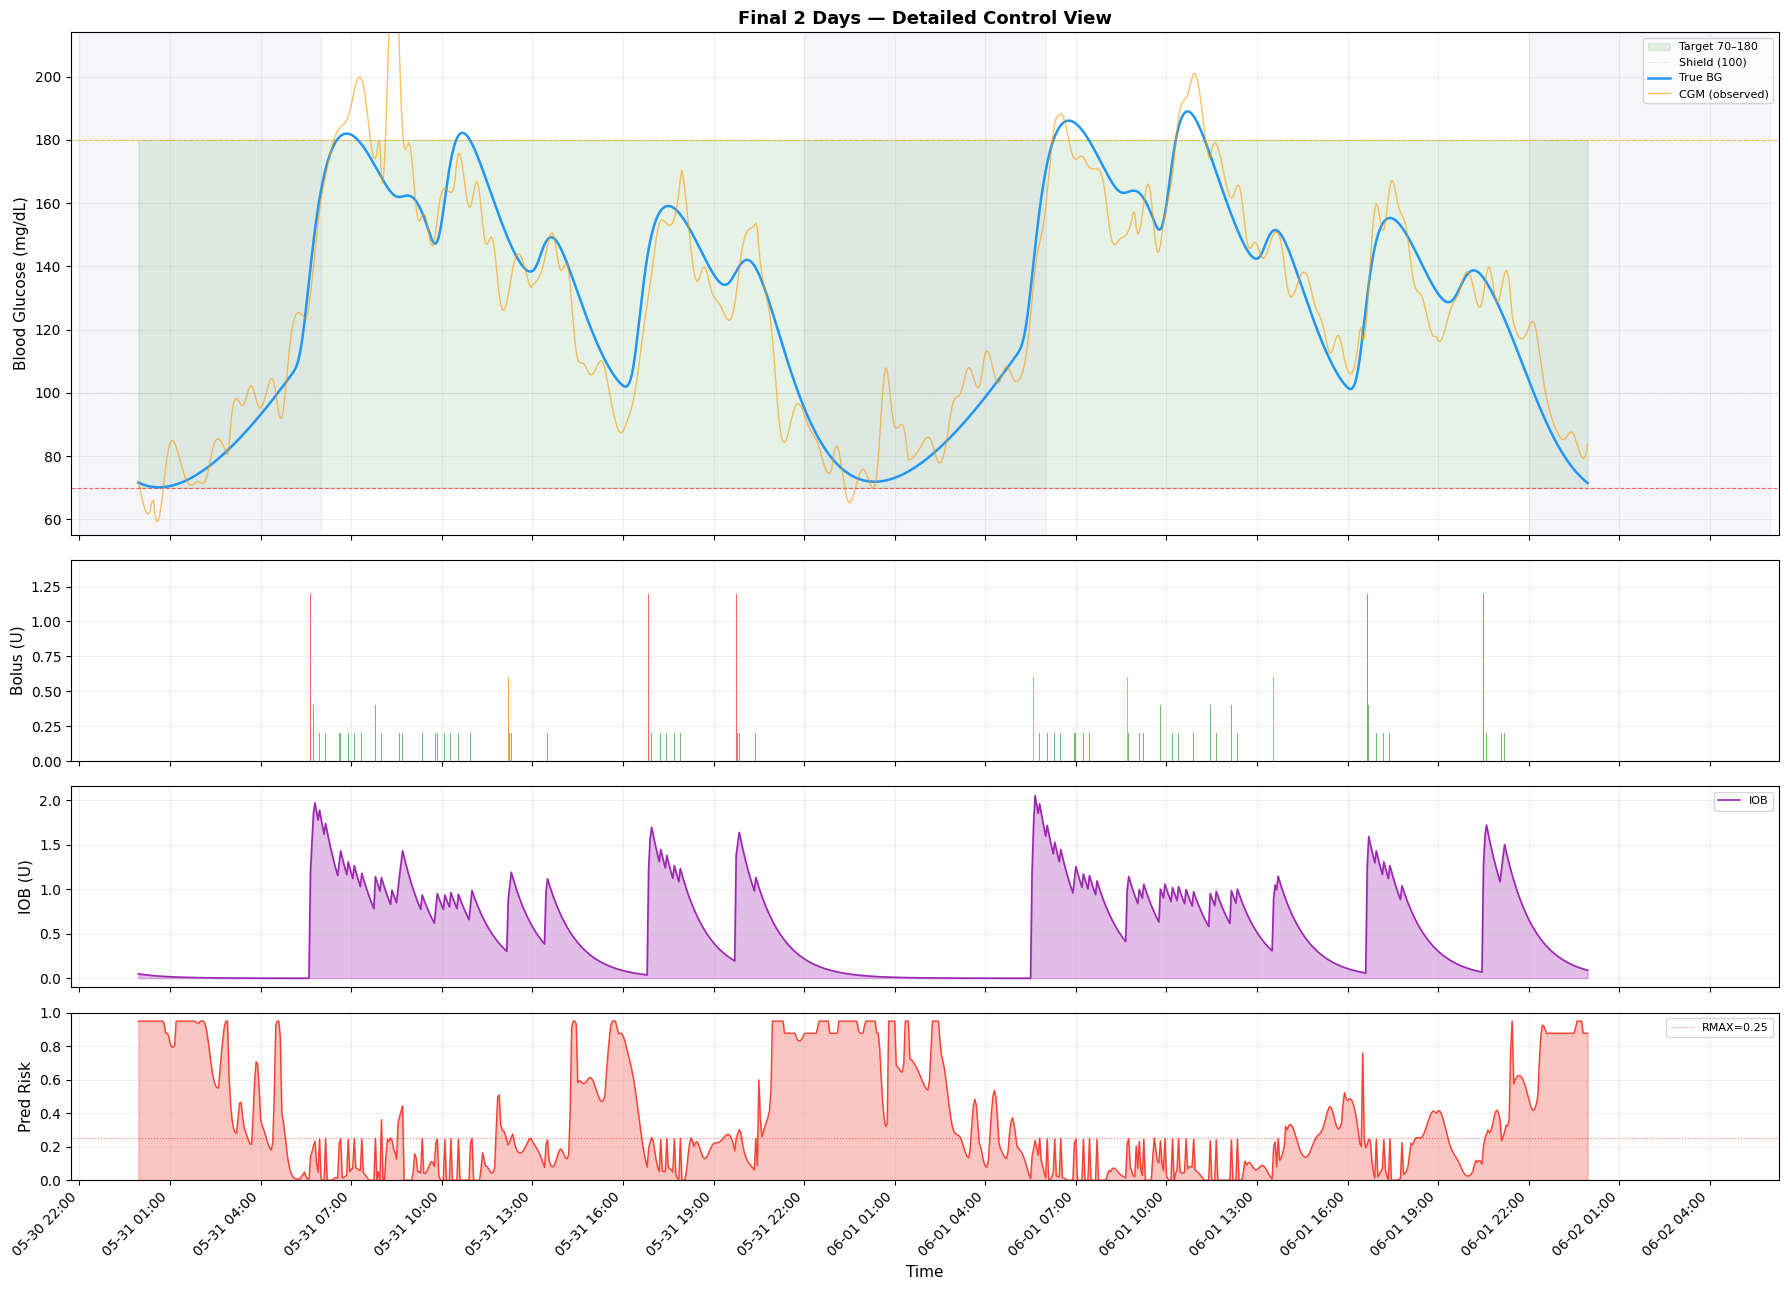


Bi-Hourly Snapshot (last 48h):
                Time      BG     CGM  bolus    IOB   Risk   mode
----------------------------------------------------------------------
 2025-05-30 23:57:00    71.6    71.9   0.00   0.05  0.950   eval
 2025-05-31 01:57:00    74.5    71.9   0.00   0.01  0.937   eval
 2025-05-31 03:57:00    92.6    95.3   0.00   0.00  0.549   eval
 2025-05-31 05:57:00   161.3   157.8   0.20   1.89  0.245   eval
 2025-05-31 07:57:00   169.0   178.6   0.00   0.98  0.000   eval
 2025-05-31 09:57:00   151.5   161.6   0.00   0.86  0.004   eval
 2025-05-31 11:57:00   154.6   128.1   0.00   0.37  0.332   eval
 2025-05-31 13:57:00   145.5   138.6   0.00   0.70  0.186   eval
 2025-05-31 15:57:00   102.7    87.4   0.00   0.09  0.878   eval
 2025-05-31 17:57:00   155.8   170.5   0.00   1.17  0.000   eval
 2025-05-31 19:57:00   141.3   145.7   0.00   1.48  0.225   eval
 2025-05-31 21:57:00    96.5    94.6   0.00   0.23  0.853   eval
 2025-05-31 23:57:00    72.4    75.9   0.00   0.03  

In [12]:
# ==============================================================================
# Plot Final 2 Days of Simulation — Detailed Control Analysis
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Extract the last 48 hours of data ---
last_time = pd.to_datetime(df_all['Time'].iloc[-1])
start_48h = last_time - pd.Timedelta(hours=48)

# Reconstruct IOB trace for full df_all
iob_trace = []
iob = 0.0
decay = 0.95
for b in df_all['bolus'].values:
    iob = iob * decay + b
    iob_trace.append(iob)
df_all['IOB_trace'] = iob_trace

df_2d = df_all[pd.to_datetime(df_all['Time']) >= start_48h].copy()
df_2d['Time'] = pd.to_datetime(df_2d['Time'])

if 'insulin_1h' not in df_2d.columns:
    df_2d['insulin_1h'] = df_2d['insulin'].rolling(20, min_periods=1).sum()

print(f"{'='*90}")
print(f"LAST 48H rows={len(df_2d)}  from {df_2d['Time'].iloc[0]} to {df_2d['Time'].iloc[-1]}")
print(f"{'='*90}")

bg = df_2d['BG'].values
tir = np.mean((bg >= 70) & (bg <= 180)) * 100
below70 = np.mean(bg < 70) * 100
above180 = np.mean(bg > 180) * 100
print(f"Last 2 Days:  TIR={tir:.1f}%  |  <70={below70:.1f}%  |  >180={above180:.1f}%  |  "
      f"MeanBG={np.mean(bg):.1f}  |  Min={np.min(bg):.1f}  |  Max={np.max(bg):.1f}")
print(f"Total bolus: {df_2d['bolus'].sum():.2f} U  |  "
      f"Num boluses: {(df_2d['bolus'] > 0).sum()}  |  "
      f"Max single: {df_2d['bolus'].max():.2f} U")
print(f"{'='*90}\n")

# --- Figure: 4-panel detailed view ---
fig, axes = plt.subplots(4, 1, figsize=(18, 13), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2, 1]})
t = df_2d['Time']

# Panel 1: BG + CGM
ax1 = axes[0]
ax1.fill_between(t, 70, 180, alpha=0.10, color='green', label='Target 70–180')
ax1.axhline(70, color='red', ls='--', lw=0.8, alpha=0.6)
ax1.axhline(180, color='orange', ls='--', lw=0.8, alpha=0.6)
ax1.axhline(100, color='gray', ls=':', lw=0.6, alpha=0.4, label='Shield (100)')
ax1.plot(t, df_2d['BG'], lw=1.8, color='#2196F3', label='True BG')
if 'CGM' in df_2d.columns:
    ax1.plot(t, df_2d['CGM'], lw=1.0, color='#FF9800', alpha=0.6, label='CGM (observed)')

# Mark meals
if 'CHO' in df_2d.columns:
    meals = df_2d[df_2d['CHO'] > 0]
    for _, row in meals.iterrows():
        ax1.axvline(row['Time'], color='green', ls='--', alpha=0.3, lw=0.8)
        ax1.annotate(f"{row['CHO']:.0f}g",
                     xy=(row['Time'], ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 250),
                     fontsize=7, color='green', ha='center', va='top')

# Shade night periods (22:00–06:00)
for day_offset in range(3):
    night_start = start_48h.normalize() + pd.Timedelta(days=day_offset, hours=22)
    night_end = start_48h.normalize() + pd.Timedelta(days=day_offset + 1, hours=6)
    ax1.axvspan(night_start, night_end, alpha=0.04, color='navy')

ax1.set_ylabel('Blood Glucose (mg/dL)', fontsize=11)
ax1.set_title('Final 2 Days — Detailed Control View', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(max(0, bg.min() - 15), min(350, bg.max() + 25))

# Panel 2: Bolus
ax2 = axes[1]
colors = ['#4CAF50' if b <= 0.4 else '#FF9800' if b <= 1.0 else '#F44336'
          for b in df_2d['bolus']]
ax2.bar(t, df_2d['bolus'], width=0.001, color=colors, alpha=0.8)
ax2.set_ylabel('Bolus (U)', fontsize=11)
ax2.set_ylim(0, max(0.5, df_2d['bolus'].max() * 1.2))

# Panel 3: IOB
ax3 = axes[2]
ax3.fill_between(t, 0, df_2d['IOB_trace'], alpha=0.3, color='#9C27B0')
ax3.plot(t, df_2d['IOB_trace'], lw=1.2, color='#9C27B0', label='IOB')
ax3.set_ylabel('IOB (U)', fontsize=11)
ax3.legend(loc='upper right', fontsize=8)

# Panel 4: Risk
ax4 = axes[3]
if 'Pred_Risk' in df_2d.columns:
    ax4.fill_between(t, 0, df_2d['Pred_Risk'], alpha=0.3, color='#F44336')
    ax4.plot(t, df_2d['Pred_Risk'], lw=1.0, color='#F44336')
    ax4.axhline(0.25, color='red', ls=':', lw=0.8, alpha=0.5, label='RMAX=0.25')
    ax4.legend(loc='upper right', fontsize=8)
ax4.set_ylabel('Pred Risk', fontsize=11)
ax4.set_ylim(0, 1.0)

# X-axis formatting for 2 days
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax4.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax4.set_xlabel('Time', fontsize=11)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

for ax in axes:
    ax.grid(True, alpha=0.2)
    ax.margins(x=0.005)

plt.tight_layout()
plt.show()

# --- Hourly snapshot table (every 2 hours for 48h) ---
print("\nBi-Hourly Snapshot (last 48h):")
print(f"{'Time':>20s} {'BG':>7s} {'CGM':>7s} {'bolus':>6s} {'IOB':>6s} {'Risk':>6s} {'mode':>6s}")
print("-" * 70)
for h in range(0, 48, 2):
    target_time = start_48h + pd.Timedelta(hours=h)
    idx = (df_2d['Time'] - target_time).abs().idxmin()
    row = df_2d.loc[idx]
    risk_val = row.get('Pred_Risk', 0.0)
    print(f"{str(row['Time']):>20s} {row['BG']:7.1f} {row['CGM']:7.1f} "
          f"{row['bolus']:6.2f} {row['IOB_trace']:6.2f} {risk_val:6.3f} {row['mode']:>6s}")

In [4]:
# ==============================================================================
# Last 2 Days — Full 3-Minute Detail Debug Table
# ==============================================================================

last_time = pd.to_datetime(df_all['Time'].iloc[-1])
start_48h = last_time - pd.Timedelta(hours=48)

# Reconstruct IOB trace
iob_trace = []
iob = 0.0
decay = 0.95
for b in df_all['bolus'].values:
    iob = iob * decay + b
    iob_trace.append(iob)
df_all['IOB_trace'] = iob_trace

# Reconstruct dCGM (delta CGM per step)
df_all['dCGM'] = df_all['CGM'].diff().fillna(0.0)

df_2d = df_all[pd.to_datetime(df_all['Time']) >= start_48h].copy()
df_2d['Time'] = pd.to_datetime(df_2d['Time'])

print(f"{'='*130}")
print(f"LAST 48H FULL DEBUG  rows={len(df_2d)}  from {df_2d['Time'].iloc[0]} to {df_2d['Time'].iloc[-1]}")
print(f"{'='*130}")

# Column header
print(f"{'Time':>20s} {'BG':>7s} {'CGM':>7s} {'dCGM':>6s} {'bolus':>6s} "
      f"{'IOB':>6s} {'ins_1h':>6s} {'Risk':>6s} {'mode':>5s}")
print("-" * 130)

for _, row in df_2d.iterrows():
    risk_val = row.get('Pred_Risk', 0.0)
    ins_1h = row.get('insulin_1h', 0.0)
    dcgm = row.get('dCGM', 0.0)
    iob_val = row.get('IOB_trace', 0.0)

    # Highlight rows where bolus > 0 AND cgm is dropping
    flag = ""
    if row['bolus'] > 0 and dcgm < -1.0:
        flag = " <<< BOLUS WHILE DROPPING"
    elif row['bolus'] > 0 and row['CGM'] < 100:
        flag = " <<< BOLUS WHILE LOW CGM"
    elif row['BG'] < 70:
        flag = " *** HYPO ***"
    elif row['BG'] < 54:
        flag = " *** SEVERE HYPO ***"

    print(f"{str(row['Time']):>20s} {row['BG']:7.1f} {row['CGM']:7.1f} {dcgm:+6.1f} "
          f"{row['bolus']:6.2f} {iob_val:6.2f} {ins_1h:6.3f} {risk_val:6.3f} "
          f"{row['mode']:>5s}{flag}")

print(f"{'='*130}")

# Summary of flagged events
bolus_while_drop = df_2d[(df_2d['bolus'] > 0) & (df_2d['dCGM'] < -1.0)]
bolus_while_low = df_2d[(df_2d['bolus'] > 0) & (df_2d['CGM'] < 100)]
hypo_rows = df_2d[df_2d['BG'] < 70]

print(f"\n--- FLAGGED EVENTS SUMMARY ---")
print(f"Bolus while CGM dropping (dCGM < -1):  {len(bolus_while_drop)} events, "
      f"total insulin: {bolus_while_drop['bolus'].sum():.2f} U")
print(f"Bolus while CGM < 100:                  {len(bolus_while_low)} events, "
      f"total insulin: {bolus_while_low['bolus'].sum():.2f} U")
print(f"Time in hypo (BG < 70):                 {len(hypo_rows)} steps "
      f"({len(hypo_rows)*3} min, {len(hypo_rows)/len(df_2d)*100:.1f}%)")

if len(bolus_while_drop) > 0:
    print(f"\n--- DETAIL: Bolus while CGM dropping ---")
    print(f"{'Time':>20s} {'BG':>7s} {'CGM':>7s} {'dCGM':>6s} {'bolus':>6s} {'IOB':>6s} {'Risk':>6s}")
    print("-" * 70)
    for _, row in bolus_while_drop.iterrows():
        print(f"{str(row['Time']):>20s} {row['BG']:7.1f} {row['CGM']:7.1f} "
              f"{row['dCGM']:+6.1f} {row['bolus']:6.2f} {row['IOB_trace']:6.2f} "
              f"{row.get('Pred_Risk', 0.0):6.3f}")

LAST 48H FULL DEBUG  rows=961  from 2025-05-30 23:57:00 to 2025-06-01 23:57:00
                Time      BG     CGM   dCGM  bolus    IOB ins_1h   Risk  mode
----------------------------------------------------------------------------------------------------------------------------------
 2025-05-30 23:57:00    62.5    62.9   -1.8   0.00   0.08  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:00:00    62.2    60.8   -2.1   0.00   0.08  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:03:00    62.0    58.5   -2.2   0.00   0.07  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:06:00    61.8    56.4   -2.1   0.00   0.07  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:09:00    61.6    54.5   -1.9   0.00   0.07  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:12:00    61.4    53.1   -1.4   0.00   0.06  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:15:00    61.2    52.4   -0.7   0.00   0.06  0.000  0.950  eval *** HYPO ***
 2025-05-31 00:18:00    61.1    52.5   +0.1   0.00   0.06  0.000  0.950  ev

# Replicate Test

In [13]:
# ==============================================================================
# Replication Test — adult#001 through adult#010
# ==============================================================================
# Paste this cell at the bottom of your notebook after the main simulation.
# It runs the full train+eval pipeline for each of the 10 adult patients
# and collects metrics into a summary table.
# ==============================================================================

import time as _time

# --- Patient list ---
patient_ids = [f"adult#0{i:02d}" for i in range(1, 11)]
# ['adult#001', 'adult#002', ..., 'adult#010']

all_patient_results = []

for pid in patient_ids:
    print(f"\n{'='*80}")
    print(f"  RUNNING PATIENT: {pid}")
    print(f"{'='*80}")
    t0 = _time.time()

    # --- Build patient-specific metadata ---
    meta_p = {
        "seed": 42,
        "patient": pid,
        "sensor": "Dexcom",
        "start_time": "2025-04-19T21:00:00",
        "meals": [
            {"hour": 8,  "minute": 0,  "grams": 50.0},
            {"hour": 12, "minute": 30, "grams": 70.0},
            {"hour": 16, "minute": 0,  "grams": 15.0},
            {"hour": 19, "minute": 0,  "grams": 60.0},
        ],
        "controller": {
            "type": "MealBolusOnlyController",
            "basal_per_min": 0.006,
            "icr_g_per_u": 25.0,
        },
    }

    # --- Build teacher ---
    teacher_p = MealBolusTeacher(
        basal_per_min=meta_p['controller']['basal_per_min'],
        icr_g_per_u=meta_p['controller']['icr_g_per_u'],
        cf_mg_per_u=50.0,
        target_bg=130.0,
    )

    # --- Build controller (fresh for each patient) ---
    ctrl_p = CompressedRiskGatedRLController(
        action_set=(0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0),
        basal_u_per_min=meta_p['controller']['basal_per_min'],
        seed=meta_p['seed'],

        teacher=teacher_p,
        warmup_steps=2000,

        safe_low=70.0,
        safe_high=180.0,
        risk_threshold=0.25,

        pulse_window=8,
        pulse_hid=64,
        pulse_lr=1e-3,
        pulse_buffer_size=10000,
        pulse_batch_size=64,
        pulse_train_every=4,

        gamma=0.99,
        lr=3e-4,
        ensemble_M=5,
        replay_size=20000,
        batch_size=128,
        train_every=4,
        lambda_risk=0.99,
        device="cpu",
        debug=False,  # quiet for batch runs

        eps_start=0.3,
        eps_end=0.02,
        eps_decay_steps=5000,
    )

    np.random.seed(meta_p['seed'])

    # --- Time span ---
    sim_start_dt_p = pd.to_datetime(meta_p['start_time'])
    train_end_dt_p = pd.to_datetime("2025-05-19T00:00:00")
    eval_days_p = 14
    sim_end_dt_p = train_end_dt_p + pd.Timedelta(days=eval_days_p)

    delta_days_p = (sim_end_dt_p - sim_start_dt_p) / pd.Timedelta(days=1)
    total_days_p = max(1, int(np.ceil(delta_days_p)))

    # --- Environment ---
    env_p, scen_p = _make_env_multiday(meta_p, start_dt=sim_start_dt_p,
                                       total_days=total_days_p)

    rst_p = env_p.reset()
    if isinstance(rst_p, (tuple, list)) and len(rst_p) >= 1:
        obs_p = rst_p[0]
        info_p = rst_p[1] if len(rst_p) > 1 else {}
    else:
        obs_p, info_p = rst_p, {}

    now_p = scen_p.start_time
    step_min_p = _env_step_minutes(env_p)

    res_p = {
        'Time': [], 'BG': [], 'CGM': [], 'CHO': [], 'insulin': [],
        'LBGI': [], 'HBGI': [], 'Risk': [], 'Pred_Risk': [],
        'mode': [], 'bolus': [], 'basal_per_min': [],
    }

    last_reward_p = 0.0
    done_p = False

    # --- Simulation loop ---
    while (now_p < sim_end_dt_p) and (not done_p):
        is_training_p = (pd.to_datetime(now_p) < train_end_dt_p)

        act_p = ctrl_p.policy(
            obs_p, last_reward_p, done_p,
            time=now_p, current_time=now_p, sample_time=step_min_p, env=env_p
        )

        pred_risk_p = ctrl_p._prev_risk_taken if ctrl_p._prev_risk_taken is not None else 0.0

        bolus_p = float(getattr(act_p, 'bolus', 0.0))
        basal_p = float(getattr(act_p, 'basal', 0.0))
        insulin_p = basal_p * float(step_min_p) + bolus_p

        cgm_val_p = _get_cgm(obs_p, info_p, env_p)

        obs_p, _, done_p, info_p = _gym_step(env_p, act_p)
        if done_p:
            print(f"  [{pid}] DONE (crashed) at {now_p}")

        bg_val_p = get_true_bg(obs_p, info_p, env_p)
        step_reward_p = rl_shaped_reward(bg_val_p, last_bolus=bolus_p)

        lbgi_p, hbgi_p, risk_p = _kovatchev_risk(bg_val_p)

        res_p['Time'].append(pd.to_datetime(now_p))
        res_p['BG'].append(bg_val_p)
        res_p['CGM'].append(cgm_val_p)
        res_p['CHO'].append(0.0)
        res_p['insulin'].append(insulin_p)
        res_p['LBGI'].append(lbgi_p)
        res_p['HBGI'].append(hbgi_p)
        res_p['Risk'].append(risk_p)
        res_p['Pred_Risk'].append(pred_risk_p)
        res_p['mode'].append('train' if is_training_p else 'eval')
        res_p['bolus'].append(bolus_p)
        res_p['basal_per_min'].append(basal_p)

        last_reward_p = step_reward_p
        now_p = pd.to_datetime(now_p) + pd.Timedelta(minutes=step_min_p)

    # --- Collect results ---
    df_p = pd.DataFrame(res_p)
    df_eval_p = df_p[df_p['mode'] == 'eval'].copy()

    elapsed = _time.time() - t0

    if len(df_eval_p) > 0:
        bg_eval = df_eval_p['BG'].values
        tir = float(np.mean((bg_eval >= 70) & (bg_eval <= 180)) * 100)
        below54 = float(np.mean(bg_eval < 54) * 100)
        below70 = float(np.mean(bg_eval < 70) * 100)
        above180 = float(np.mean(bg_eval > 180) * 100)
        above250 = float(np.mean(bg_eval > 250) * 100)
        mean_bg = float(np.mean(bg_eval))
        std_bg = float(np.std(bg_eval))
        min_bg = float(np.min(bg_eval))
        max_bg = float(np.max(bg_eval))
        total_bolus = float(df_eval_p['bolus'].sum())
        lbgi_mean = float(df_eval_p['LBGI'].mean())
        hbgi_mean = float(df_eval_p['HBGI'].mean())

        patient_metrics = {
            'patient': pid,
            'TIR_%': round(tir, 2),
            'Time<70_%': round(below70, 2),
            'Time<54_%': round(below54, 2),
            'Time>180_%': round(above180, 2),
            'Time>250_%': round(above250, 2),
            'MeanBG': round(mean_bg, 1),
            'StdBG': round(std_bg, 1),
            'MinBG': round(min_bg, 1),
            'MaxBG': round(max_bg, 1),
            'LBGI': round(lbgi_mean, 2),
            'HBGI': round(hbgi_mean, 2),
            'TotalBolus_U': round(total_bolus, 1),
            'EvalSteps': len(df_eval_p),
            'Crashed': done_p and len(df_eval_p) < 6000,
            'Time_sec': round(elapsed, 1),
        }
    else:
        patient_metrics = {
            'patient': pid,
            'TIR_%': 0.0,
            'Time<70_%': 0.0,
            'Time<54_%': 0.0,
            'Time>180_%': 0.0,
            'Time>250_%': 0.0,
            'MeanBG': np.nan,
            'StdBG': np.nan,
            'MinBG': np.nan,
            'MaxBG': np.nan,
            'LBGI': np.nan,
            'HBGI': np.nan,
            'TotalBolus_U': 0.0,
            'EvalSteps': 0,
            'Crashed': True,
            'Time_sec': round(elapsed, 1),
        }

    all_patient_results.append(patient_metrics)

    print(f"  [{pid}] TIR={patient_metrics['TIR_%']:.1f}%  "
          f"<70={patient_metrics['Time<70_%']:.1f}%  "
          f">180={patient_metrics['Time>180_%']:.1f}%  "
          f"MeanBG={patient_metrics['MeanBG']}  "
          f"Crashed={patient_metrics['Crashed']}  "
          f"({elapsed:.0f}s)")

# ==============================================================================
# Summary Table
# ==============================================================================
df_summary = pd.DataFrame(all_patient_results)

print(f"\n{'='*100}")
print("REPLICATION RESULTS — 10 Virtual Adults (14-day eval)")
print(f"{'='*100}")
print(df_summary[['patient', 'TIR_%', 'Time<70_%', 'Time<54_%', 'Time>180_%',
                   'MeanBG', 'StdBG', 'LBGI', 'HBGI', 'Crashed']].to_string(index=False))

print(f"\n{'='*100}")
print("AGGREGATE STATISTICS")
print(f"{'='*100}")
valid = df_summary[~df_summary['Crashed']]
if len(valid) > 0:
    print(f"Patients completed: {len(valid)} / {len(df_summary)}")
    print(f"TIR (70-180):   {valid['TIR_%'].mean():.1f} ± {valid['TIR_%'].std():.1f}%")
    print(f"Time < 70:      {valid['Time<70_%'].mean():.1f} ± {valid['Time<70_%'].std():.1f}%")
    print(f"Time < 54:      {valid['Time<54_%'].mean():.1f} ± {valid['Time<54_%'].std():.1f}%")
    print(f"Time > 180:     {valid['Time>180_%'].mean():.1f} ± {valid['Time>180_%'].std():.1f}%")
    print(f"Time > 250:     {valid['Time>250_%'].mean():.1f} ± {valid['Time>250_%'].std():.1f}%")
    print(f"Mean BG:        {valid['MeanBG'].mean():.1f} ± {valid['MeanBG'].std():.1f} mg/dL")
    print(f"LBGI:           {valid['LBGI'].mean():.2f} ± {valid['LBGI'].std():.2f}")
    print(f"HBGI:           {valid['HBGI'].mean():.2f} ± {valid['HBGI'].std():.2f}")
    print(f"Avg runtime:    {valid['Time_sec'].mean():.0f}s per patient")
else:
    print("All patients crashed!")

# --- Save to CSV ---
csv_path = "replication_results.csv"
df_summary.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")


  RUNNING PATIENT: adult#001
  [adult#001] TIR=95.7%  <70=1.6%  >180=2.8%  MeanBG=126.9  Crashed=False  (139s)

  RUNNING PATIENT: adult#002
  [adult#002] TIR=98.0%  <70=0.0%  >180=2.0%  MeanBG=130.2  Crashed=False  (142s)

  RUNNING PATIENT: adult#003
  [adult#003] TIR=93.6%  <70=0.7%  >180=5.7%  MeanBG=134.0  Crashed=False  (151s)

  RUNNING PATIENT: adult#004
  [adult#004] TIR=63.7%  <70=27.0%  >180=9.3%  MeanBG=108.4  Crashed=False  (137s)

  RUNNING PATIENT: adult#005
  [adult#005] TIR=84.0%  <70=0.0%  >180=16.0%  MeanBG=151.7  Crashed=False  (155s)

  RUNNING PATIENT: adult#006
  [adult#006] TIR=74.7%  <70=0.0%  >180=25.3%  MeanBG=150.1  Crashed=False  (162s)

  RUNNING PATIENT: adult#007
  [adult#007] TIR=79.9%  <70=15.6%  >180=4.5%  MeanBG=109.1  Crashed=False  (150s)

  RUNNING PATIENT: adult#008
  [adult#008] TIR=99.0%  <70=0.7%  >180=0.4%  MeanBG=115.6  Crashed=False  (132s)

  RUNNING PATIENT: adult#009
  [adult#009] TIR=54.3%  <70=1.1%  >180=44.6%  MeanBG=158.3  Crashed=F